# Mixed-effects + GAM аналіз SpO2 ~ FiO2

Ноутбук оцінює нелінійний вплив FiO2 на SpO2 з урахуванням повторних вимірювань по пацієнтах через mixed-effects модель.

Кроки:
1. Завантаження/перевірка `df`.
2. Очищення, нормалізація FiO2, підготовка ознак.
3. EDA графіки.
4. MixedLM baseline/linear/spline + додаткові перевірки.
5. Порівняння моделей, bootstrap CI ефекту, діагностика.
6. Збереження результатів.


In [1]:
import warnings, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from patsy import dmatrix
from scipy import stats
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM

# warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)
random.seed(42)

CONFIG = {
    "seed": 42,
    "spo2_min": 50.0,
    "spo2_max": 100.0,
    "fio2_min": 0.21,
    "fio2_max": 1.00,
    "ks": [6,8,10],
    "plot_patient_cap": 20,
    "traj_patient_cap": 4,
    "downsample_rule": None,
    "enable_oxygen_support_filter": True,
    "enable_pvalue_filter": False,
    "pvalue_column": "p_value",
    "pvalue_threshold": 0.05,
    "enable_optional_covariates": True,
    "bootstrap_iters": 200,
    "save_dir": Path("./results"),
}
CONFIG


{'seed': 42,
 'spo2_min': 50.0,
 'spo2_max': 100.0,
 'fio2_min': 0.21,
 'fio2_max': 1.0,
 'ks': [6, 8, 10],
 'plot_patient_cap': 20,
 'traj_patient_cap': 4,
 'downsample_rule': None,
 'enable_oxygen_support_filter': True,
 'enable_pvalue_filter': False,
 'pvalue_column': 'p_value',
 'pvalue_threshold': 0.05,
 'enable_optional_covariates': True,
 'bootstrap_iters': 200,
 'save_dir': WindowsPath('results')}

In [2]:
if "df" not in globals():
    from trs_dataset import TRSDataset
    loader = TRSDataset("work/stat")
    df = loader.load_all(max_workers=8, use_cache=True)

required = ["patient_id","time","SpO2","FiO2"]
miss = [c for c in required if c not in df.columns]
if miss:
    raise ValueError(f"Missing required columns: {miss}")

print(f"Rows={len(df):,}, Patients={df['patient_id'].nunique():,}")
display(df.head())
display(df.dtypes)
display(df[required].isna().mean().to_frame("missing_fraction"))
display(df[["SpO2","FiO2"]].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T)


Rows=2,516,732, Patients=16,224


,patient_id,time,SpO2,FiO2
0,10001884,0,99.0,0.5
1,10001884,1,100.0,0.5
2,10001884,2,95.0,0.5
3,10001884,3,100.0,0.5
4,10001884,4,98.0,0.5


patient_id        str
time            int64
SpO2          float64
FiO2          float64
dtype: object

,missing_fraction
patient_id,0.0
time,0.0
SpO2,0.0
FiO2,0.0


,count,mean,std,min,1%,5%,50%,95%,99%,max
SpO2,2516732.0,96.855534,2.79191,80.0,88.0,92.0,97.0,100.00,100.0,100.0
FiO2,2516732.0,0.480913,0.16118,0.2,0.3,0.3,0.4,0.98,1.0,1.0


In [3]:
def normalize_fio2(df: pd.DataFrame) -> pd.DataFrame:
    # Normalize FiO2 scale to fraction
    out = df.copy()
    med = out["FiO2"].dropna().median()
    if pd.notna(med) and med > 1.5:
        out["FiO2"] = out["FiO2"] / 100.0
        print("FiO2 converted from percent to fraction.")
    else:
        print("FiO2 treated as fraction scale.")
    return out

def _oxygen_mask(d: pd.DataFrame) -> pd.Series:
    m = pd.Series(True, index=d.index)
    if "FiO2" in d.columns:
        m &= d["FiO2"] > 0.21
    cand = [c for c in d.columns if any(k in c.lower() for k in ["support","device","oxygen","mode"])]
    if cand:
        c = cand[0]
        mm = d[c].astype(str).str.lower().str.contains("o2|oxygen|vent|hf|cpap|bipap|mask|cannula", regex=True, na=False)
        if mm.any():
            m &= mm
            print(f"oxygen support column used: {c}")
    return m

def clean_data(df_raw: pd.DataFrame, config: dict) -> pd.DataFrame:
    d = normalize_fio2(df_raw)
    d["SpO2"] = pd.to_numeric(d["SpO2"], errors="coerce")
    d["FiO2"] = pd.to_numeric(d["FiO2"], errors="coerce")
    t = pd.to_datetime(d["time"], errors="coerce")
    d["time"] = t if t.notna().mean() > 0.5 else pd.to_numeric(d["time"], errors="coerce")
    d = d[(d["SpO2"]>=config["spo2_min"]) & (d["SpO2"]<=config["spo2_max"])]
    d = d[(d["FiO2"]>=config["fio2_min"]) & (d["FiO2"]<=config["fio2_max"])]
    d = d.dropna(subset=["patient_id","time","SpO2","FiO2"]).copy()
    if config["enable_oxygen_support_filter"]:
        m = _oxygen_mask(d)
        if m.any():
            d = d[m].copy()
    pcol = config["pvalue_column"]
    if config["enable_pvalue_filter"] and pcol in d.columns:
        d[pcol] = pd.to_numeric(d[pcol], errors="coerce")
        d = d[d[pcol] < config["pvalue_threshold"]].copy()
    d["patient_id"] = d["patient_id"].astype(str)
    d = d.sort_values(["patient_id","time"]).reset_index(drop=True)
    d["FiO2_c"] = d["FiO2"] - d["FiO2"].mean()
    return d

def maybe_downsample(d: pd.DataFrame, rule: str|None) -> pd.DataFrame:
    if not rule:
        return d.copy()
    if not np.issubdtype(d["time"].dtype, np.datetime64):
        print("time is not datetime, downsample skipped")
        return d.copy()
    chunks=[]
    for pid,g in d.groupby("patient_id", sort=False):
        g2 = g.set_index("time").resample(rule).mean(numeric_only=True)
        g2["patient_id"] = pid
        chunks.append(g2.reset_index())
    out = pd.concat(chunks, ignore_index=True).dropna(subset=["SpO2","FiO2"])
    out = out.sort_values(["patient_id","time"]).reset_index(drop=True)
    out["FiO2_c"] = out["FiO2"] - out["FiO2"].mean()
    return out

df_clean = clean_data(df, CONFIG)
analysis_df = maybe_downsample(df_clean, CONFIG["downsample_rule"])
print(f"analysis rows={len(analysis_df):,}, patients={analysis_df['patient_id'].nunique():,}")
display(analysis_df.head())


FiO2 treated as fraction scale.
analysis rows=2,510,430, patients=16,205


,patient_id,time,SpO2,FiO2,FiO2_c
0,10001884,1970-01-01 00:00:00.000000000,99.0,0.5,0.018406
1,10001884,1970-01-01 00:00:00.000000001,100.0,0.5,0.018406
2,10001884,1970-01-01 00:00:00.000000002,95.0,0.5,0.018406
3,10001884,1970-01-01 00:00:00.000000003,100.0,0.5,0.018406
4,10001884,1970-01-01 00:00:00.000000004,98.0,0.5,0.018406


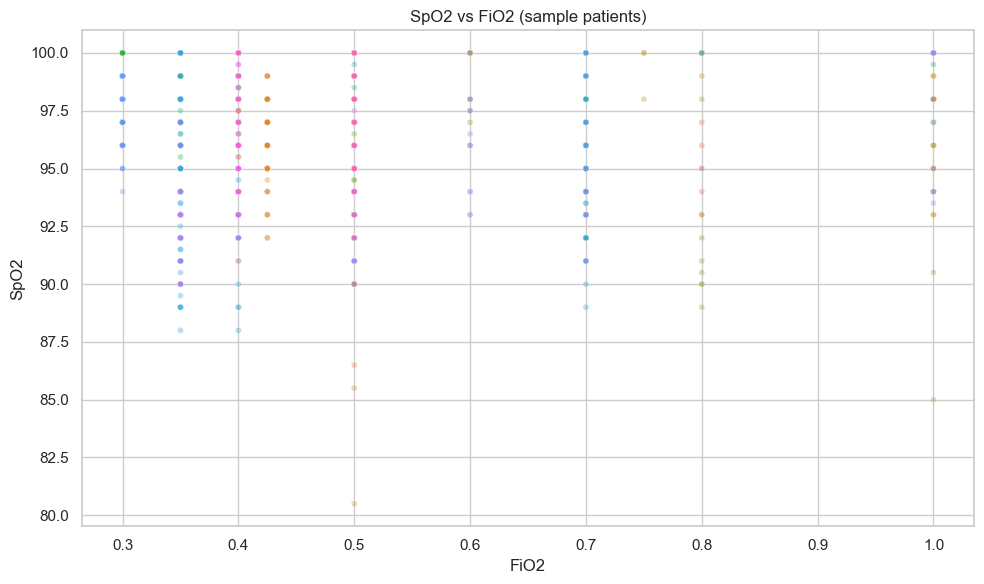

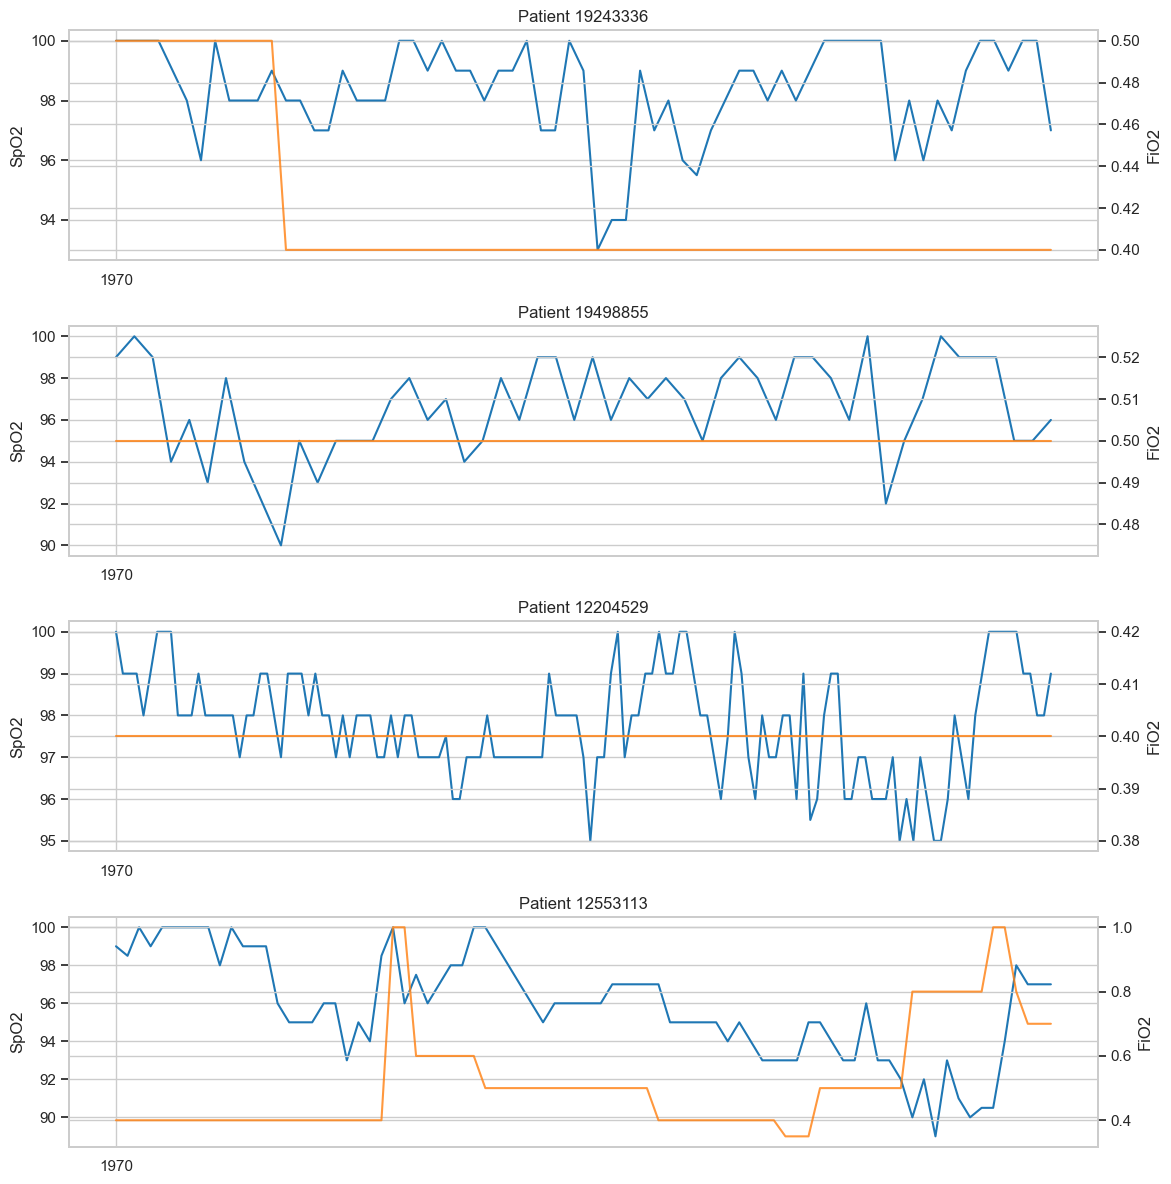

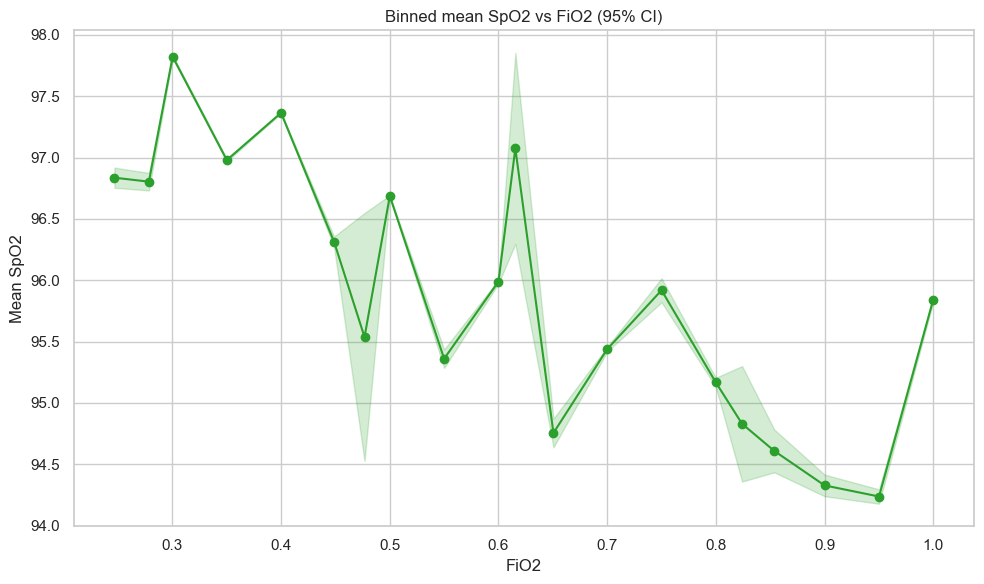

In [4]:
save_dir = Path(CONFIG["save_dir"])
save_dir.mkdir(parents=True, exist_ok=True)

# Scatter
pp = analysis_df["patient_id"].drop_duplicates().sample(n=min(CONFIG["plot_patient_cap"], analysis_df["patient_id"].nunique()), random_state=CONFIG["seed"])
pdf = analysis_df[analysis_df["patient_id"].isin(pp)]
plt.figure(figsize=(10,6))
sns.scatterplot(data=pdf, x="FiO2", y="SpO2", hue="patient_id", alpha=0.35, s=18, legend=False)
plt.title("SpO2 vs FiO2 (sample patients)")
plt.tight_layout(); plt.savefig(save_dir/"plot_scatter_spo2_fio2.png", dpi=150); plt.show()

# Trajectories
pt = analysis_df["patient_id"].drop_duplicates().sample(n=min(CONFIG["traj_patient_cap"], analysis_df["patient_id"].nunique()), random_state=CONFIG["seed"])
fig, axes = plt.subplots(len(pt),1, figsize=(12,3*len(pt)), sharex=False)
if len(pt)==1: axes=[axes]
for ax,pid in zip(axes, pt):
    g = analysis_df[analysis_df["patient_id"]==pid].sort_values("time")
    ax2 = ax.twinx()
    ax.plot(g["time"], g["SpO2"], color="tab:blue")
    ax2.plot(g["time"], g["FiO2"], color="tab:orange", alpha=0.8)
    ax.set_title(f"Patient {pid}")
    ax.set_ylabel("SpO2"); ax2.set_ylabel("FiO2")
fig.tight_layout(); plt.savefig(save_dir/"plot_time_series_patients.png", dpi=150); plt.show()

# Binned summary
b = analysis_df[["FiO2","SpO2"]].copy(); b["bin"] = pd.cut(b["FiO2"], bins=20, include_lowest=True)
b = b.groupby("bin", observed=False).agg(fio2=("FiO2","mean"), mean=("SpO2","mean"), std=("SpO2","std"), n=("SpO2","size")).dropna()
b["se"] = b["std"] / np.sqrt(b["n"].clip(lower=1)); b["lo"] = b["mean"]-1.96*b["se"]; b["hi"] = b["mean"]+1.96*b["se"]
plt.figure(figsize=(10,6)); plt.plot(b["fio2"], b["mean"], marker="o", color="tab:green")
plt.fill_between(b["fio2"], b["lo"], b["hi"], alpha=0.2, color="tab:green")
plt.xlabel("FiO2"); plt.ylabel("Mean SpO2"); plt.title("Binned mean SpO2 vs FiO2 (95% CI)")
plt.tight_layout(); plt.savefig(save_dir/"plot_binned_spo2_fio2.png", dpi=150); plt.show()


In [5]:
def build_spline_basis(df: pd.DataFrame, K: int) -> pd.DataFrame:
    x = dmatrix(f"bs(FiO2, df={K}, degree=3, include_intercept=False)-1", data=df, return_type="dataframe")
    x.columns = [f"bs_{i}" for i in range(x.shape[1])]
    return x

def pick_optional_covariates(d: pd.DataFrame) -> tuple[list[str], list[str]]:
    if not CONFIG["enable_optional_covariates"]:
        return [], []
    blocked = {"SpO2","FiO2","FiO2_c","patient_id","time"}
    num=[]; cat=[]
    for c in d.columns:
        if c in blocked: continue
        lc = c.lower()
        if any(k in lc for k in ["rr","hr","heart","resp","bp","map","temp"]) and pd.api.types.is_numeric_dtype(d[c]):
            num.append(c)
        elif any(k in lc for k in ["mode","device","support"]):
            nu = d[c].nunique(dropna=True)
            if 2 <= nu <= 8: cat.append(c)
    return list(dict.fromkeys(num)), list(dict.fromkeys(cat))

def add_cov(exog: pd.DataFrame, d: pd.DataFrame, num: list[str], cat: list[str]) -> pd.DataFrame:
    out = exog.copy()
    for c in num:
        v = pd.to_numeric(d[c], errors="coerce")
        out[c] = v.fillna(v.median())
    for c in cat:
        dm = pd.get_dummies(d[c].astype(str).fillna("missing"), prefix=c, drop_first=True, dtype=float)
        out = pd.concat([out, dm], axis=1)
    return out

def fit_mixed(endog, exog, groups, exog_re, name="model"):
    for method in ["lbfgs","cg","powell"]:
        try:
            m = MixedLM(endog=endog, exog=exog, groups=groups, exog_re=exog_re)
            r = m.fit(reml=False, method=method, maxiter=300, disp=False)
            return r, method
        except Exception:
            pass
    print(f"{name} failed")
    return None, None

def fit_models(df: pd.DataFrame, K: int) -> dict:
    d = df.dropna(subset=["SpO2","FiO2","FiO2_c","patient_id"]).copy()
    y = d["SpO2"].astype(float); g = d["patient_id"].astype(str)
    num_cov, cat_cov = pick_optional_covariates(d)

    xb = add_cov(pd.DataFrame({"const":1.0}, index=d.index), d, num_cov, cat_cov)
    xl = add_cov(pd.DataFrame({"const":1.0, "FiO2_c":d["FiO2_c"].values}, index=d.index), d, num_cov, cat_cov)
    xs = add_cov(pd.concat([pd.DataFrame({"const":1.0}, index=d.index), build_spline_basis(d,K)], axis=1), d, num_cov, cat_cov)
    xre_i = pd.DataFrame({"const_re":1.0}, index=d.index)

    rb, mb = fit_mixed(y, xb, g, xre_i, f"baseline_K{K}")
    rl, ml = fit_mixed(y, xl, g, xre_i, f"linear_K{K}")
    rs, ms = fit_mixed(y, xs, g, xre_i, f"spline_K{K}")

    xsr = xs.copy(); xsr["FiO2_c"] = d["FiO2_c"].values
    xre_s = pd.DataFrame({"const_re":1.0, "FiO2_c_re":d["FiO2_c"].values}, index=d.index)
    rsr, msr = fit_mixed(y, xsr, g, xre_s, f"spline_rs_K{K}")

    dl = d.copy(); dl["SpO2_lag1"] = dl.groupby("patient_id")["SpO2"].shift(1); dl = dl.dropna(subset=["SpO2_lag1"])
    rlag = None; mlag = None
    if len(dl) > 100:
        y2 = dl["SpO2"].astype(float); g2 = dl["patient_id"].astype(str)
        xl2 = add_cov(pd.concat([pd.DataFrame({"const":1.0}, index=dl.index), build_spline_basis(dl,K), pd.DataFrame({"SpO2_lag1":dl["SpO2_lag1"].values}, index=dl.index)], axis=1), dl, num_cov, cat_cov)
        rlag, mlag = fit_mixed(y2, xl2, g2, pd.DataFrame({"const_re":1.0}, index=dl.index), f"spline_lag_K{K}")

    return {"K":K, "data":d, "num_cov":num_cov, "cat_cov":cat_cov, "baseline":rb, "linear":rl, "spline":rs, "spline_rs":rsr, "spline_lag":rlag,
            "methods":{"baseline":mb,"linear":ml,"spline":ms,"spline_rs":msr,"spline_lag":mlag}}

def metrics(res, K, name):
    if res is None: return {"K":K,"model":name,"n_params":np.nan,"llf":np.nan,"aic":np.nan,"bic":np.nan,"converged":False}
    return {"K":K,"model":name,"n_params":len(res.params),"llf":res.llf,"aic":res.aic,"bic":res.bic,"converged":bool(getattr(res,"converged",True))}

def lrt(r0, r1, label):
    if (r0 is None) or (r1 is None): return {"comparison":label, "lr_stat":np.nan, "df_diff":np.nan, "p_value":np.nan}
    lr = 2*(r1.llf-r0.llf); dd = len(r1.params)-len(r0.params); p = np.nan if dd<=0 else stats.chi2.sf(lr, dd)
    return {"comparison":label, "lr_stat":lr, "df_diff":dd, "p_value":p}


In [6]:
all_bundles={}; rows=[]
for K in CONFIG["ks"]:
    print(f"Fitting K={K}")
    b = fit_models(analysis_df, K)
    all_bundles[K]=b
    for name in ["baseline","linear","spline","spline_rs","spline_lag"]:
        rows.append(metrics(b[name], K, name))

metrics_df = pd.DataFrame(rows).sort_values(["K","model"]).reset_index(drop=True)
display(metrics_df)

smx = metrics_df[metrics_df["model"]=="spline"].dropna(subset=["aic"])
if smx.empty:
    raise RuntimeError("No converged spline model.")
best_K = int(smx.loc[smx["aic"].idxmin(), "K"])
best_bundle = all_bundles[best_K]
print("Best K:", best_K)

lrt_rows=[]
for K,b in all_bundles.items():
    lrt_rows.append({"K":K, **lrt(b["baseline"], b["linear"], "baseline vs linear")})
    lrt_rows.append({"K":K, **lrt(b["linear"], b["spline"], "linear vs spline (approx)")})
lrt_df = pd.DataFrame(lrt_rows)
display(lrt_df)


Fitting K=6


d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceW

Fitting K=8


d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceW

Fitting K=10


d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
d:\TEMP\KPI\Test_ANOVA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceW

,K,model,n_params,llf,aic,bic,converged
0,6,baseline,2,inf,-inf,-inf,True
1,6,linear,3,inf,-inf,-inf,True
2,6,spline,8,-5.661504e+06,1.132303e+07,1.132314e+07,True
3,6,spline_lag,9,inf,-inf,-inf,True
4,6,spline_rs,11,-5.613444e+06,1.122691e+07,1.122706e+07,True
5,8,baseline,2,inf,-inf,-inf,True
6,8,linear,3,inf,-inf,-inf,True
7,8,spline,10,inf,-inf,-inf,True
8,8,spline_lag,11,inf,-inf,-inf,True
9,8,spline_rs,13,-5.612419e+06,1.122487e+07,1.122505e+07,True


Best K: 8


C:\Users\jon\AppData\Local\Temp\ipykernel_14348\2280075008.py:76: RuntimeWarning: invalid value encountered in scalar subtract
  lr = 2*(r1.llf-r0.llf); dd = len(r1.params)-len(r0.params); p = np.nan if dd<=0 else stats.chi2.sf(lr, dd)


,K,comparison,lr_stat,df_diff,p_value
0,6,baseline vs linear,NaN,1,NaN
1,6,linear vs spline (approx),-inf,5,1.0
2,8,baseline vs linear,NaN,1,NaN
3,8,linear vs spline (approx),NaN,7,NaN
4,10,baseline vs linear,NaN,1,NaN
5,10,linear vs spline (approx),NaN,9,NaN


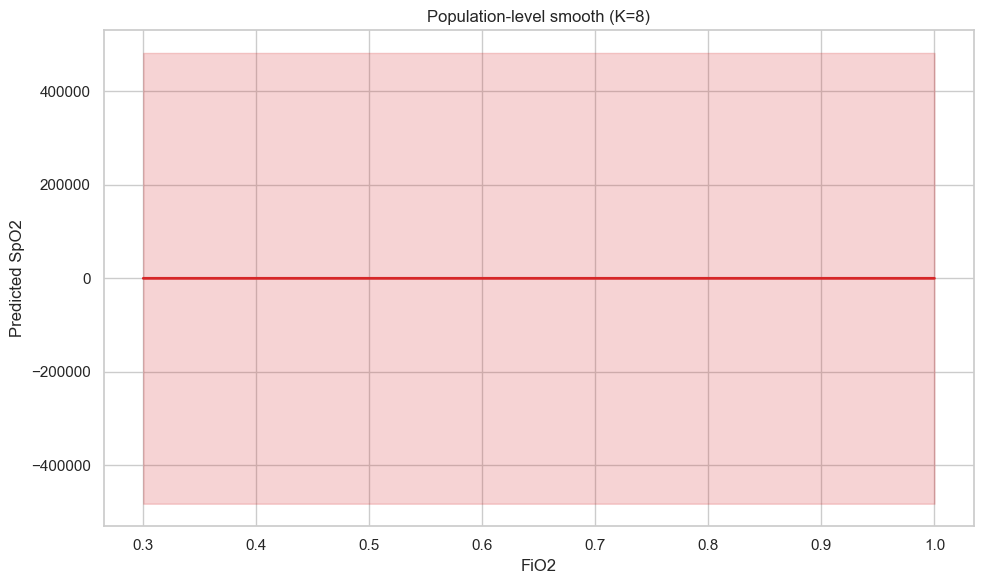

KeyboardInterrupt: 

In [7]:
def make_exog_for_grid(grid: pd.DataFrame, bundle: dict, key: str="spline") -> pd.DataFrame:
    dref = bundle["data"]; K = bundle["K"]
    g = grid.copy(); g["FiO2_c"] = g["FiO2"] - dref["FiO2"].mean()
    if key=="linear":
        x = pd.DataFrame({"const":1.0, "FiO2_c":g["FiO2_c"].values}, index=g.index)
    else:
        x = pd.concat([pd.DataFrame({"const":1.0}, index=g.index), build_spline_basis(g,K)], axis=1)
        if key=="spline_rs": x["FiO2_c"] = g["FiO2_c"].values
    for c in bundle["num_cov"]:
        x[c] = pd.to_numeric(dref[c], errors="coerce").median()
    for c in bundle["cat_cov"]:
        rv = dref[c].astype(str).mode(dropna=True)
        rv = rv.iloc[0] if len(rv) else "missing"
        dm = pd.get_dummies(pd.Series([rv]*len(g), index=g.index), prefix=c, drop_first=True, dtype=float)
        x = pd.concat([x, dm], axis=1)
    needed = list(bundle[key].model.exog_names)
    for c in needed:
        if c not in x.columns: x[c]=0.0
    return x[needed]

def predict_curve(bundle: dict, key: str="spline", n: int=140) -> pd.DataFrame:
    m = bundle[key]; d = bundle["data"]
    grid = pd.DataFrame({"FiO2":np.linspace(float(d["FiO2"].quantile(0.01)), float(d["FiO2"].quantile(0.99)), n)})
    x = make_exog_for_grid(grid, bundle, key)
    p = m.params.reindex(x.columns)
    y = x.values @ p.values
    v = m.cov_params().loc[x.columns, x.columns].values
    se = np.sqrt(np.einsum("ij,jk,ik->i", x.values, v, x.values))
    out = grid.copy(); out["SpO2_pred"]=y; out["ci_low"]=y-1.96*se; out["ci_high"]=y+1.96*se
    return out

def _fit_bootstrap_spline(d: pd.DataFrame, bundle: dict):
    y = d["SpO2"].astype(float); g = d["patient_id"].astype(str)
    x = pd.concat([pd.DataFrame({"const":1.0}, index=d.index), build_spline_basis(d, bundle["K"])], axis=1)
    x = add_cov(x, d, bundle["num_cov"], bundle["cat_cov"])
    r,_ = fit_mixed(y, x, g, pd.DataFrame({"const_re":1.0}, index=d.index), "bootstrap")
    return r

def cluster_bootstrap_ci(df: pd.DataFrame, model: dict, grid: pd.DataFrame) -> dict:
    # Cluster bootstrap by patient for effect difference CI
    ids = df["patient_id"].astype(str).drop_duplicates().values
    rng = np.random.default_rng(CONFIG["seed"])
    diffs=[]
    a,b = float(grid["FiO2"].min()), float(grid["FiO2"].max())
    for bi in range(int(CONFIG["bootstrap_iters"])):
        s = rng.choice(ids, size=len(ids), replace=True)
        parts=[]
        for j,pid in enumerate(s):
            g = df[df["patient_id"].astype(str)==pid].copy(); g["patient_id"] = g["patient_id"].astype(str)+f"_b{j}"
            parts.append(g)
        bd = pd.concat(parts, ignore_index=True).dropna(subset=["SpO2","FiO2","FiO2_c","patient_id"])
        r = _fit_bootstrap_spline(bd, model)
        if r is None: continue
        ex = make_exog_for_grid(pd.DataFrame({"FiO2":[a,b]}), model, "spline")
        pv = r.params.reindex(ex.columns).fillna(0.0)
        yh = ex.values @ pv.values
        diffs.append(float(yh[1]-yh[0]))
    if len(diffs)<20:
        return {"n_boot":len(diffs), "effect_diff":np.nan, "ci_low":np.nan, "ci_high":np.nan}
    q = np.quantile(diffs,[0.025,0.5,0.975])
    return {"n_boot":len(diffs), "effect_diff":float(q[1]), "ci_low":float(q[0]), "ci_high":float(q[2])}

curve_df = predict_curve(best_bundle, "spline", 140)
plt.figure(figsize=(10,6)); plt.plot(curve_df["FiO2"], curve_df["SpO2_pred"], color="tab:red", lw=2)
plt.fill_between(curve_df["FiO2"], curve_df["ci_low"], curve_df["ci_high"], color="tab:red", alpha=0.2)
plt.xlabel("FiO2"); plt.ylabel("Predicted SpO2"); plt.title(f"Population-level smooth (K={best_K})")
plt.tight_layout(); plt.savefig(save_dir/"plot_population_smooth_curve.png", dpi=150); plt.show()

omin, omax = float(best_bundle["data"]["FiO2"].min()), float(best_bundle["data"]["FiO2"].max())
fa, fb = min(max(0.21,omin),omax), min(max(0.60,omin),omax)
eff_grid = pd.DataFrame({"FiO2":[fa,fb]})
ex = make_exog_for_grid(eff_grid, best_bundle, "spline")
pv = best_bundle["spline"].params.reindex(ex.columns)
point_diff = float((ex.values @ pv.values)[1] - (ex.values @ pv.values)[0])
boot_ci = cluster_bootstrap_ci(best_bundle["data"], best_bundle, eff_grid)
print(f"Effect ?SpO2 for FiO2 {fa:.2f}->{fb:.2f}: {point_diff:.3f}")
print("Cluster bootstrap:", boot_ci)


In [8]:
m = best_bundle["spline"]
resid = m.resid; fitted = m.fittedvalues
fig,ax = plt.subplots(1,3, figsize=(16,4.5))
ax[0].scatter(fitted,resid,alpha=0.25,s=10); ax[0].axhline(0,color="black",lw=1); ax[0].set_title("Residuals vs fitted")
sm.qqplot(resid, line="45", ax=ax[1], fit=True); ax[1].set_title("QQ plot")
re = [np.atleast_1d(np.asarray(v,dtype=float))[0] for v in m.random_effects.values()]
ax[2].hist(re, bins=30, color="tab:purple", alpha=0.8); ax[2].set_title("Random intercepts")
plt.tight_layout(); plt.savefig(save_dir/"plot_model_diagnostics.png", dpi=150); plt.show()

dh = best_bundle["data"][["FiO2"]].copy(); dh["resid"] = resid; dh["bin"] = pd.cut(dh["FiO2"], bins=12, include_lowest=True)
het = dh.groupby("bin", observed=False).agg(fio2=("FiO2","mean"), resid_var=("resid","var")).dropna()
plt.figure(figsize=(9,5)); plt.plot(het["fio2"], het["resid_var"], marker="o")
plt.title("Residual variance across FiO2 bins"); plt.xlabel("FiO2"); plt.ylabel("Residual variance")
plt.tight_layout(); plt.savefig(save_dir/"plot_heteroscedasticity_check.png", dpi=150); plt.show()

sens = metrics_df[metrics_df["model"].isin(["linear","spline"])].pivot(index="K", columns="model", values="aic")
sens["delta_aic_spline_minus_linear"] = sens["spline"]-sens["linear"]
display(sens)
pnl = lrt_df[(lrt_df["K"]==best_K) & (lrt_df["comparison"]=="linear vs spline (approx)")]
pnl = float(pnl["p_value"].iloc[0]) if not pnl.empty else np.nan
daic = float(sens.loc[best_K, "delta_aic_spline_minus_linear"]) if best_K in sens.index else np.nan
supported = (np.isfinite(daic) and daic < -2) or (np.isfinite(pnl) and pnl < 0.05)
print("Нелінійний ефект FiO2 підтримується." if supported else "Переконливих доказів нелінійності не виявлено.")
print(f"Best K={best_K}, delta AIC={daic:.3f}, p(linear vs spline)={pnl:.4g}")
print(f"Bootstrap CI ?SpO2: [{boot_ci['ci_low']:.3f}, {boot_ci['ci_high']:.3f}] (n={boot_ci['n_boot']})")

mode_cols = [c for c in analysis_df.columns if ("mode" in c.lower() or "support" in c.lower())]
if mode_cols:
    mc = mode_cols[0]; rows=[]
    for mv in analysis_df[mc].value_counts(dropna=False).head(3).index:
        sub = analysis_df[analysis_df[mc]==mv].copy()
        if sub["patient_id"].nunique()<10 or len(sub)<500: continue
        try:
            sb = fit_models(sub, best_K)
            rows.append({"mode":str(mv), "n_rows":len(sub), "n_patients":sub["patient_id"].nunique(),
                         "aic_linear": np.nan if sb["linear"] is None else sb["linear"].aic,
                         "aic_spline": np.nan if sb["spline"] is None else sb["spline"].aic})
        except Exception as e:
            print("stratified fit error:", e)
    if rows:
        sdf = pd.DataFrame(rows); sdf["delta_aic_spline_minus_linear"] = sdf["aic_spline"]-sdf["aic_linear"]
        display(sdf); sdf.to_csv(save_dir/"stratified_mode_model_comparison.csv", index=False)
else:
    print("Mode/support column not found, stratified section skipped.")

summary = metrics_df[["K","model","n_params","llf","aic","bic","converged"]].sort_values(["model","K"])
display(summary)
summary.to_csv(save_dir/"model_comparison_summary.csv", index=False)
lrt_df.to_csv(save_dir/"model_lrt_comparison.csv", index=False)
curve_df.to_csv(save_dir/"population_smooth_curve.csv", index=False)
print("Artifacts saved to", save_dir.resolve())


ValueError: Cannot predict random effects from singular covariance structure.